# Load Packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using LsqFit
using BlackBoxOptim
using LaTeXStrings
using JLD2
using BlackBoxOptim: num_func_evals
using LatinHypercubeSampling
using Gtk

include("ModelFunctionsAll.jl")

findTTP (generic function with 1 method)

# Load Data and Pyruvate T1s

In [3]:
# With this block it will open a Julia window where we need to select the "temporaldataALL.csv file generated by the Python code.
# this file will be located in the experimental folder, not in the folder with the 13Cdata. Make sure you are in the corresponding folder not the one from the previous analysis.
# Once selected this file, the kinetic data will be loaded and can proceed with the next steps.
using Gtk
filename = open_dialog("Load Data for Fitting! ;) ")

barr = findall("\\", filename)[end][1];
pathD = filename[1:barr];
filNam = filename[barr+1:end];

### Delay between start scan and injection (INTRODUCED BY USER!!!!!!!!!!)

In [240]:
# INTRODUCE manually the Start scan time in seconds and the Start Injection time 
# From this point onwards the script may run without user intervention.

startScan = 9
StartInject = 14


global dela = convert(Int, round((StartInject-startScan)/5));

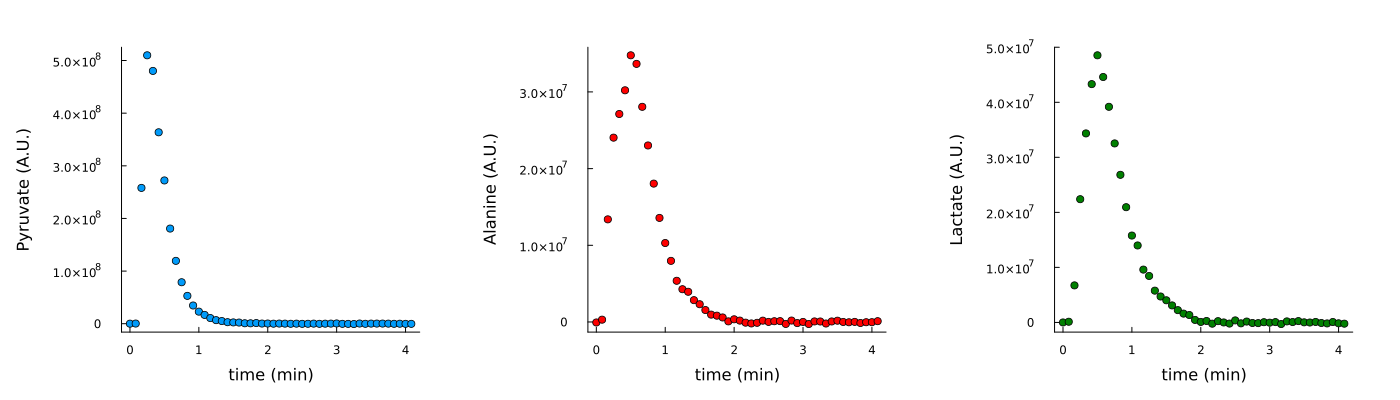

In [241]:
# Load and plot experimental data generated by the DataProcGEN_Magnitude SCRIPT
global dat2 = Matrix(CSV.read(filename, DataFrame));

dat2[:,2] = dat2[:,2].-mean(dat2[:,2][end-10:end])
dat2[:,3] = dat2[:,3].-mean(dat2[:,3][end-10:end])
dat2[:,4] = dat2[:,4].-mean(dat2[:,4][end-10:end])

ss1 = scatter(dat2[:,1]./60, dat2[:,2], label = "", grid = false, xlabel = "time (min)", ylabel = "Pyruvate (A.U.)")
ss2 = scatter(dat2[:,1]./60, dat2[:,3], label = "", grid = false, xlabel = "time (min)", ylabel = "Alanine (A.U.)", color = "red")
ss3 = scatter(dat2[:,1]./60, dat2[:,4], label = "", grid = false, xlabel = "time (min)", ylabel = "Lactate (A.U.)", color = "green")

plot(ss1, ss2, ss3, layout = (1,3), size = (1400, 400), margin = 10mm)

# T1 Approximations

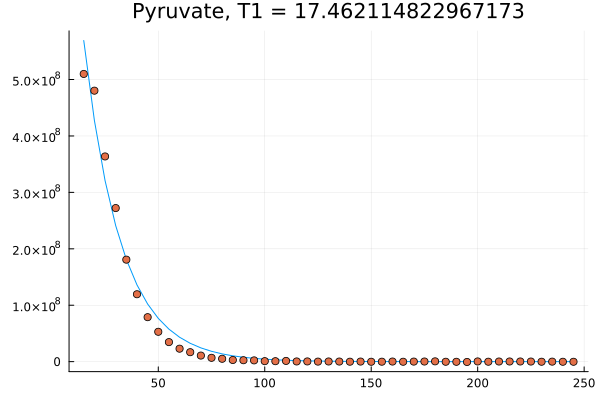

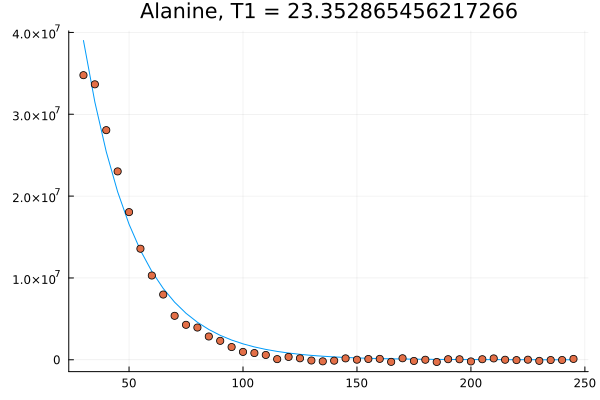

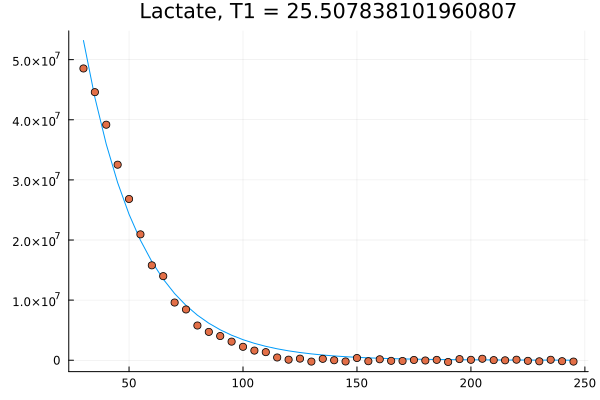

In [242]:
T1s = T1Approx(dat2);

# Parameter Estimation

In [243]:
# Testing and initialising function. Does nothing for you, but you need to run it. 
ObjectFunctME([1,1,1,1,1,1,1,100000])

21.07245386440568

In [244]:
isfile(pathD*"\\"*filNam[1:end-4]*"_resM.jld2")

true

****************************************************************
*              THIS PROCESS WILL TAKE ABOUT 2 MIN!             *
****************************************************************
Starting optimization with optimizer DiffEvoOpt{FitPopulation{Float64}, RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, RandomBound{ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
0.50 secs, 372 evals, 278 steps, improv/step: 0.489 (last = 0.4892), fitness=11.270269557
1.00 secs, 871 evals, 776 steps, improv/step: 0.454 (last = 0.4337), fitness=4.370206916
1.50 secs, 1439 evals, 1344 steps, improv/step: 0.396 (last = 0.3169), fitness=3.877666182
2.00 secs, 2006 evals, 1911 steps, improv/step: 0.342 (last = 0.2134), fitness=3.609706695
2.51 secs, 2552 evals, 2457 steps, improv/step: 0.304 (last = 0.1722), fitness=3.080910235
3.01 secs, 3095 evals, 3000 steps, improv/step: 0.288 (last = 0.2136), fitness=2.508851922
3.51 secs, 3688 evals, 3593 steps, improv/step: 0.274 (las

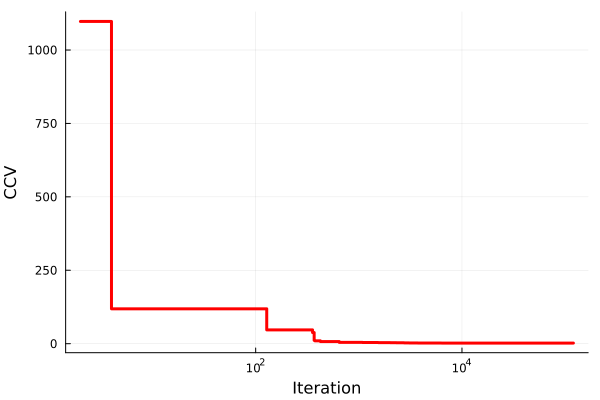

┌ Warning: Attempting to store var"#15#16"{Vector{Tuple{Int64, Float64}}}.
│ JLD2 only stores functions by name.
│  This may not be useful for anonymous functions.
└ @ JLD2 C:\Users\Vicent\.julia\packages\JLD2\phaon\src\data\writing_datatypes.jl:447
┌ Warning: Attempting to store BlackBoxOptim.var"#114#115".
│ JLD2 only stores functions by name.
│  This may not be useful for anonymous functions.
└ @ JLD2 C:\Users\Vicent\.julia\packages\JLD2\phaon\src\data\writing_datatypes.jl:447


8×1 Matrix{Float64}:
  0.08629500766506348
  0.01924365135386921
  0.32412588857446406
  0.23003625349476828
 15.71590334067067
 27.869236637376662
 25.37396315172655
  1.8022689372596512e9

In [245]:
#This part of the code will try to fit a matematical model using iterations. It may take 2 minutes to finish the fitting.
# wait until it finishes and appears the graph and the parameter matrix before running the next block

pp = EstimateParsMod(pathD, filNam, T1s, true)

#### Parameters Summary

In [247]:
println("kin_B = "*string(pp[1]))
println("kin_O = "*string(pp[2]))
println("kpl = "*string(pp[3]))
println("kal = "*string(pp[4]))
println("T1_P = "*string(pp[5]))
println("T1_L = "*string(pp[6]))
println("T1_A = "*string(pp[7]))

println("PyrO_B__0 = "*string(pp[8]))

nms = ["kin_B","kin_O","kpl","kal","T1_P","T1_L","T1_A","PyrO_B__0"]
CSV.write(pathD*"ParameterValues.csv", DataFrame(hcat(nms, pp), :auto))

kin_B = 0.08629500766506348
kin_O = 0.01924365135386921
kpl = 0.32412588857446406
kal = 0.23003625349476828
T1_P = 15.71590334067067
T1_L = 27.869236637376662
T1_A = 25.37396315172655
PyrO_B__0 = 1.8022689372596512e9


"F:\\MRI_analysis_2_HFD-NMR\\17144_5_WEEK_23___1_13C_pyr_liver_slab_1_1\\ParameterValues.csv"

#### Plot Results

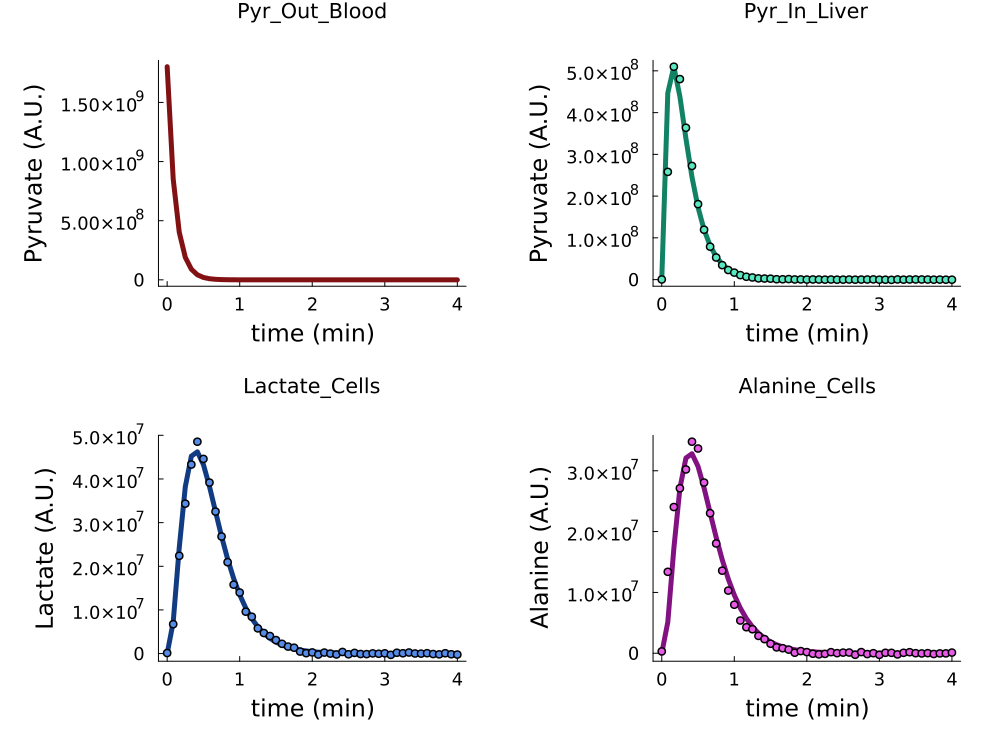

In [248]:
#Check that the graph are well adjusted to the points, and that the first point of the line is a zero in the graph
# If the first point of the line is not a zero in the pyruvate graph, adjust the startInject time
plotFit(dat2, dela, [pp[1], pp[2], pp[3], pp[4], pp[5], pp[6], pp[7], pp[8]], pathD, filNam)

### Find time of maximum peak (from mathematical equations)

In [250]:
findTTP(dat2, dela, pp, pathD, filNam)

Time to peak after injection for Pyruvate: 9.0 s
Time to peak after injection for Alanine: 23.0 s
Time to peak after injection for Lactate: 23.0 s


383

#                       THE END 